<a href="https://colab.research.google.com/github/tommypolpo/geron-hands_on_ML/blob/main/c10_regression_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Goal: implement mini-batch gradient descent

In [2]:
import torch
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

dataset = fetch_california_housing()  # only numerical, no missing values
X = dataset.data
y = dataset.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

X_train = torch.FloatTensor(X_train) #convert to tensors
X_val = torch.FloatTensor(X_val)
X_test = torch.FloatTensor(X_test)

# Normalize, we could use StandardScaler but let's do it manually
means = X_train.mean(dim=0, keepdim=True)
stds = X_train.std(dim=0, keepdim=True)
print(f'shape means: {means.shape}')

X_train = (X_train - means) / stds
X_val = (X_val - means) / stds
X_test = (X_test - means) / stds

y_train = torch.FloatTensor(y_train).reshape(-1,1)
y_val = torch.FloatTensor(y_val).reshape(-1,1)
y_test = torch.FloatTensor(y_test).reshape(-1,1)

shape means: torch.Size([1, 8])


In [3]:
# in order to implement mini-batch we need a DataLoader, and DataLoader requires the
# tensors to be wrapped in a dataset object

from torch.utils.data import TensorDataset, DataLoader

# create a dataset object
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [4]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [5]:
import torch.nn as nn
torch.manual_seed(42)
model=nn.Sequential(
    nn.Linear(8, 50),
    nn.ReLU(),
    nn.Linear(50, 40),
    nn.ReLU(),
    nn.Linear(40, 1)
)

model = model.to(device)

In [6]:
# training function
learning_rate = 0.01
n_epochs = 20

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

def train(model, optimizer, criterion, train_loader, n_epochs):
  model.train()
  for epoch in range(n_epochs):
    total_loss=0
    for X_batch, y_batch in train_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)
      y_pred = model(X_batch)
      loss = criterion(y_pred, y_batch)
      total_loss += loss.item()
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
    mean_loss = total_loss / len(train_loader)
    print(f'Epoch {epoch+1}/{n_epochs}, Loss: {mean_loss:.4f}')



In [7]:
train(model, optimizer, mse, train_loader, n_epochs)

Epoch 1/20, Loss: 0.6682
Epoch 2/20, Loss: 0.4630
Epoch 3/20, Loss: 0.4230
Epoch 4/20, Loss: 0.4051
Epoch 5/20, Loss: 0.3939
Epoch 6/20, Loss: 0.3810
Epoch 7/20, Loss: 0.3726
Epoch 8/20, Loss: 0.3638
Epoch 9/20, Loss: 0.3572
Epoch 10/20, Loss: 0.3583
Epoch 11/20, Loss: 0.3484
Epoch 12/20, Loss: 0.3438
Epoch 13/20, Loss: 0.3435
Epoch 14/20, Loss: 0.3355
Epoch 15/20, Loss: 0.3315
Epoch 16/20, Loss: 0.3281
Epoch 17/20, Loss: 0.3244
Epoch 18/20, Loss: 0.3232
Epoch 19/20, Loss: 0.3186
Epoch 20/20, Loss: 0.3157


In [8]:
# define an evaluation function
# metric_fn: metric/function to evaluate a batch
# aggregate_fn: metric/function to aggregate the batch metrics

def evaluate(model, data_loader, metric_fn, aggregate_fn=torch.mean):
  model.eval()
  metrics = []
  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)
      y_pred = model(X_batch)
      metric = metric_fn(y_pred, y_batch)
      metrics.append(metric)
  return aggregate_fn(torch.stack(metrics))

In [9]:
valid_loader = DataLoader(val_dataset, batch_size=32) # already wrapped in dataset above
test_loader = DataLoader(test_dataset, batch_size=32) # already wrapped in dataset above


valid_mse = evaluate(model, valid_loader, metric_fn=mse)
print(f'Validation MSE: {valid_mse:.4f}')



Validation MSE: 0.3164


The mean of the batch-MSEs is the total MSE

In [10]:
def rmse(y_pred, y_true):
  return ((y_pred-y_true)**2).mean().sqrt()

evaluate(model, valid_loader, metric_fn=rmse)


tensor(0.5540, device='cuda:0')

In [11]:
# note that this is not the square root of the MSE, i.e. the global RMSE
valid_mse.sqrt()

tensor(0.5625, device='cuda:0')

In [12]:
# to compute the RMSE we modifity the aggregate function and use mse on each batch
evaluate(model, valid_loader, metric_fn=mse,
         aggregate_fn=lambda metrics: torch.sqrt(torch.mean(metrics)))

tensor(0.5625, device='cuda:0')

In [13]:
pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.1 MB/s eta 0:00:00


In [14]:
# This evaluation function checks how our model performs on a given dataset
# (formatted as a DataLoader).
# We can choose any metric we want (like RMSE).
#
# The function works batch-by-batch but correctly calculates the metric for the WHOLE dataset.
# This is important: for metrics like RMSE, the global score is NOT just a simple average
# of the batch scores. The combination of 'metric.update()' and 'metric.compute()' handles
# this complex math flawlessly.
#
# Notice 'model.eval()': this tells the computer we are evaluating, not training.
# Notice 'metric.reset()': this is mandatory to wipe out any old data from previous runs
# so we get a pure, fresh score.

import torchmetrics

def evaluate_tm(model, data_loader, metric):
  model.eval()
  metric.reset()
  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)
      y_pred = model(X_batch)
      metric.update(y_pred, y_batch) #update at each iteration
  return metric.compute()

rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
evaluate_tm(model, valid_loader, rmse)

tensor(0.5613, device='cuda:0')

The discrepancy is probably due to the last mini-bath having a different size.

Exercise: update the train function to evaliate the model performance during training. On the training set during each epoch and on the validation set at the end of each epoch.

In [15]:
# training function
learning_rate = 0.01
n_epochs = 20

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

def train2(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
  # Initialize lists to store history for plotting or tracking later
  train_losses = []
  train_metrics = []
  eval_metrics = []

  for epoch in range(n_epochs):
    # -------------------------------------------------------------------------
    # WHY: We MUST force the model back into training mode at the start of every epoch.
    # REASON: The validation function 'evaluate_tm' (called at the bottom of this loop)
    # changes the model to evaluation mode ('model.eval()'). If we don't switch it back
    # here, the model will train in evaluation mode for all remaining epochs.
    # Layers like Dropout and BatchNorm will stay shut off, hurting model learning.
    # -------------------------------------------------------------------------
    model.train()

    # -------------------------------------------------------------------------
    # WHY: We wipe the metric memory clean before the new epoch starts.
    # REASON: This removes any data left over from previous epochs so we get a
    # fresh, true score for this current epoch only.
    # -------------------------------------------------------------------------
    metric.reset()

    total_loss = 0
    for X_batch, y_batch in train_loader:
      # Send data to GPU/CPU memory
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      # Forward pass: get model predictions
      y_pred = model(X_batch)

      # Calculate how wrong the model is (Loss value)
      loss = criterion(y_pred, y_batch)

      # -------------------------------------------------------------------------
      # WHY: We use '.item()' to extract the raw Python number from the loss tensor.
      # REASON: If we just write 'total_loss += loss', PyTorch keeps the massive
      # mathematical graph history in memory. Doing this for thousands of batches
      # will completely overload your GPU RAM and crash your program (Out of Memory).
      # -------------------------------------------------------------------------
      total_loss += loss.item()

      # Backpropagation: Calculate gradients and update model parameters
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

      # -------------------------------------------------------------------------
      # WHY: We feed the current batch's predictions and targets into the tracker.
      # REASON: This allows torchmetrics to calculate the training performance
      # *while training is already happening*, saving huge amounts of time.
      # -------------------------------------------------------------------------
      metric.update(y_pred, y_batch)

    # Calculate average loss for this training epoch
    mean_loss = total_loss / len(train_loader)
    train_losses.append(mean_loss)

    # -------------------------------------------------------------------------
    # WHY: We call '.compute()' to calculate the single final score for the epoch,
    # and '.item()' to extract it as a standard number.
    # We could have used train_metrics.append(evaluate_tm(model, train_loader, metric)),
    # but it is not necessary to re-send all the batches to the GPU!
    # -------------------------------------------------------------------------
    train_metrics.append(metric.compute().item())

    # -------------------------------------------------------------------------
    # WHY: Run the evaluation function on the separate validation data loader.
    # NOTE: We do not call '.item()' here because the corrected version of
    # 'evaluate_tm' already returns a plain float number.
    # -------------------------------------------------------------------------
    eval_metrics.append(evaluate_tm(model, valid_loader, metric))

    # Print progress report for the current epoch
    print(f'Epoch {epoch+1}/{n_epochs}, Loss: {mean_loss:.4f}, '
          f'Train metric: {train_metrics[-1]:.4f}, '
          f'Valid metric: {eval_metrics[-1]:.4f}')
  return train_losses, train_metrics, eval_metrics

# Running the function
# Catch the returned lists from the train2 function
train_losses, train_rmse, valid_rmse = train2(model, optimizer, mse, rmse, train_loader, valid_loader, n_epochs)


Epoch 1/20, Loss: 0.3114, Train metric: 0.5581, Valid metric: 0.5940
Epoch 2/20, Loss: 0.3104, Train metric: 0.5571, Valid metric: 0.5717
Epoch 3/20, Loss: 0.3067, Train metric: 0.5538, Valid metric: 0.5681
Epoch 4/20, Loss: 0.3056, Train metric: 0.5528, Valid metric: 0.5614
Epoch 5/20, Loss: 0.3055, Train metric: 0.5527, Valid metric: 0.5615
Epoch 6/20, Loss: 0.3021, Train metric: 0.5497, Valid metric: 0.5615
Epoch 7/20, Loss: 0.3013, Train metric: 0.5489, Valid metric: 0.5571
Epoch 8/20, Loss: 0.2995, Train metric: 0.5473, Valid metric: 0.5507
Epoch 9/20, Loss: 0.2981, Train metric: 0.5460, Valid metric: 0.5564
Epoch 10/20, Loss: 0.2979, Train metric: 0.5458, Valid metric: 0.5617
Epoch 11/20, Loss: 0.2976, Train metric: 0.5455, Valid metric: 0.5529
Epoch 12/20, Loss: 0.2939, Train metric: 0.5422, Valid metric: 0.5559
Epoch 13/20, Loss: 0.2970, Train metric: 0.5450, Valid metric: 0.5603
Epoch 14/20, Loss: 0.2943, Train metric: 0.5425, Valid metric: 0.5432
Epoch 15/20, Loss: 0.2920, Tr

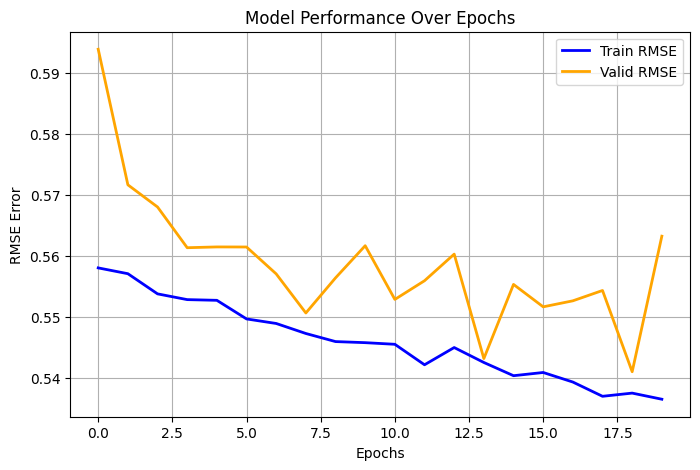

In [18]:
import matplotlib.pyplot as plt


# CONVERSION: Ensure every item in the lists is on the CPU and converted to a standard number
# (We add .cpu() just in case evaluate_tm or metric.compute() returned a GPU tensor)
train_rmse_cpu = [t.cpu().item() if hasattr(t, 'cpu') else t for t in train_rmse]
valid_rmse_cpu = [v.cpu().item() if hasattr(v, 'cpu') else v for v in valid_rmse]

# Create the plot using the converted CPU lists
plt.figure(figsize=(8, 5))
plt.plot(train_rmse_cpu, label='Train RMSE', color='blue', linewidth=2)
plt.plot(valid_rmse_cpu, label='Valid RMSE', color='orange', linewidth=2)

# Add labels and style
plt.title('Model Performance Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('RMSE Error')
plt.legend()
plt.grid(True)

# 5. Show the plot
plt.show()